# RNN/LSTM Image Captioning Notebook

Notebook utama RNN/LSTM untuk Kaggle dan lokal. Semua kebutuhan Kaggle yang dulu ada di launcher sekarang ada di notebook ini: discovery dataset Flickr8k, fallback split, mode demo/full, output directory, training RNN/LSTM, evaluasi Keras vs scratch, analisis, dan bonus.

## 0. Setup

In [2]:
import os, subprocess
from pathlib import Path

IS_KAGGLE_SETUP = Path("/kaggle/input").exists()

if IS_KAGGLE_SETUP:
    GITHUB_REPO = "https://github.com/fithrarzk/SpreiElsa.git"
    clone_dir = Path("/kaggle/working/SpreiElsa")
    if clone_dir.exists():
        subprocess.run(["git", "-C", str(clone_dir), "pull", "--rebase"], check=True)
    else:
        subprocess.run(["git", "clone", "--depth=1", GITHUB_REPO, str(clone_dir)], check=True)
    os.chdir(str(clone_dir))
    print("Repo cloned/updated from GitHub:", clone_dir)

os.environ["FLICKR8K_DATASET_SLUG"] = "adityajn105/flickr8k"
os.environ["RUN_MODE"] = "full"   #  "demo" buat tes c
    

In [2]:
import os, subprocess
from pathlib import Path

IS_KAGGLE_SETUP = Path("/kaggle/input").exists()

if IS_KAGGLE_SETUP:
    GITHUB_REPO = "https://github.com/fithrarzk/SpreiElsa.git"
    clone_dir = Path("/kaggle/working/SpreiElsa")
    if clone_dir.exists():
        subprocess.run(["git", "-C", str(clone_dir), "pull", "--rebase"], check=True)
    else:
        subprocess.run(["git", "clone", "--depth=1", GITHUB_REPO, str(clone_dir)], check=True)
    os.chdir(str(clone_dir))
    print("Repo cloned/updated from GitHub:", clone_dir)

os.environ["FLICKR8K_DATASET_SLUG"] = "adityajn105/flickr8k"
os.environ["RUN_MODE"] = "full"   #  "demo" buat tes c
    

Cloning into '/kaggle/working/SpreiElsa'...


Repo cloned/updated from GitHub: /kaggle/working/SpreiElsa


In [2]:
import csv
import json
import os
import random
import shutil
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    if (current / "src" / "notebook").exists():
        return current
    for parent in current.parents:
        if (parent / "src" / "notebook").exists():
            return parent

    input_root = Path("/kaggle/input")
    code_slug = os.getenv("CODE_DATASET_SLUG", "").strip()
    search_roots = []
    if code_slug and (input_root / code_slug).exists():
        search_roots.append(input_root / code_slug)
    if input_root.exists():
        search_roots.append(input_root)

    for root in search_roots:
        candidates = [root, *root.glob("**/*")]
        for candidate in candidates:
            if candidate.is_dir() and (candidate / "src" / "notebook").exists():
                working_copy = Path("/kaggle/working/SpreiElsa")
                if Path("/kaggle/working").exists():
                    if working_copy.exists():
                        shutil.rmtree(working_copy)
                    shutil.copytree(candidate, working_copy)
                    return working_copy
                return candidate

    raise FileNotFoundError(
        "Repo root tidak ditemukan. Jalankan notebook dari root repo atau upload repo sebagai Kaggle Dataset "
        "dan, jika perlu, isi environment CODE_DATASET_SLUG."
    )


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

RNN_SRC = REPO_ROOT / "src" / "rnn-lstm"
UTILS_SRC = REPO_ROOT / "src" / "utils"
for path in (str(REPO_ROOT), str(RNN_SRC), str(UTILS_SRC)):
    if path not in sys.path:
        sys.path.insert(0, path)

print("Repo root:", REPO_ROOT)
print("TensorFlow:", tf.__version__)

2026-05-15 01:16:22.317592: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778807782.518759      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778807782.579524      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778807783.075474      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778807783.075517      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778807783.075520      23 computation_placer.cc:177] computation placer alr

Repo root: /kaggle/working/SpreiElsa
TensorFlow: 2.19.0


In [1]:
from feature_extraction import extract_flickr8k_features, load_features
from text_utils import (
    clean_caption,
    decode_caption,
    encode_caption,
    load_flickr8k_captions,
    load_vocab,
)
import preprocess_flickr8k
from decoder_model import build_dataset, build_decoder_model, masked_accuracy, masked_loss
from train_decoder import DecoderExperimentConfig, train_one
from caption_model import CaptionModel
from evaluate_captioning import evaluate
from metrics import bleu_score, meteor_score, tokenize
from rnn import SimpleRNNCell, SimpleRNNDecoder
from lstm import LSTMCell, LSTMDecoder

ModuleNotFoundError: No module named 'feature_extraction'

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IS_KAGGLE = Path("/kaggle/input").exists()


def env_flag(name: str, default: bool) -> bool:
    raw = os.getenv(name)
    if raw is None:
        return default
    return raw.strip().lower() in {"1", "true", "yes", "y", "on"}


RUN_MODE = os.getenv("RUN_MODE", "full" if IS_KAGGLE else "local").strip().lower()
if RUN_MODE == "smoke":
    RUN_MODE = "demo"
if RUN_MODE not in {"local", "demo", "full"}:
    raise ValueError("RUN_MODE harus 'local', 'demo', atau 'full'")

DEMO_MODE = RUN_MODE == "demo"
DEMO_SYNTHETIC_FEATURES = env_flag("DEMO_SYNTHETIC_FEATURES", DEMO_MODE)

RUN_EXTRACT_FEATURES = env_flag("RUN_EXTRACT_FEATURES", IS_KAGGLE and not DEMO_SYNTHETIC_FEATURES)
RUN_PREPROCESS = env_flag("RUN_PREPROCESS", IS_KAGGLE or DEMO_MODE)
RUN_TRAIN_RNN = env_flag("RUN_TRAIN_RNN", IS_KAGGLE or DEMO_MODE)
RUN_TRAIN_LSTM = env_flag("RUN_TRAIN_LSTM", IS_KAGGLE or DEMO_MODE)
RUN_TRAIN_INIT_INJECT = env_flag("RUN_TRAIN_INIT_INJECT", IS_KAGGLE and RUN_MODE == "full")
RUN_FULL_EVAL = env_flag("RUN_FULL_EVAL", IS_KAGGLE or DEMO_MODE)

N_EVAL = int(os.getenv("N_EVAL", "5" if DEMO_MODE else "50"))
N_BATCH = int(os.getenv("N_BATCH", str(N_EVAL)))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "8" if DEMO_MODE else "64"))
EPOCHS = int(os.getenv("EPOCHS", "1" if DEMO_MODE else "30"))
FORCE_RETRAIN = env_flag("FORCE_RETRAIN", False)
MAX_SEQ_LEN = int(os.getenv("MAX_SEQ_LEN", "20" if DEMO_MODE else "35"))
EMBED_DIM = int(os.getenv("EMBED_DIM", "64" if DEMO_MODE else "256"))
FEATURE_DIM = int(os.getenv("FEATURE_DIM", "2048"))
LEARNING_RATE = float(os.getenv("LEARNING_RATE", "1e-3"))

DEMO_FLICKR_TRAIN_IMAGES = int(os.getenv("DEMO_FLICKR_TRAIN_IMAGES", "18"))
DEMO_FLICKR_VAL_IMAGES = int(os.getenv("DEMO_FLICKR_VAL_IMAGES", "4"))
DEMO_FLICKR_TEST_IMAGES = int(os.getenv("DEMO_FLICKR_TEST_IMAGES", "4"))

FULL_VARIATIONS = [
    {"n_layers": 1, "hidden_size": 128},
    {"n_layers": 1, "hidden_size": 256},
    {"n_layers": 2, "hidden_size": 128},
    {"n_layers": 2, "hidden_size": 256},
    {"n_layers": 3, "hidden_size": 128},
    {"n_layers": 3, "hidden_size": 256},
]
DEMO_VARIATIONS = [{"n_layers": 1, "hidden_size": 64}]
VARIATIONS = DEMO_VARIATIONS if DEMO_MODE else FULL_VARIATIONS

{
    "RUN_MODE": RUN_MODE,
    "IS_KAGGLE": IS_KAGGLE,
    "DEMO_SYNTHETIC_FEATURES": DEMO_SYNTHETIC_FEATURES,
    "RUN_EXTRACT_FEATURES": RUN_EXTRACT_FEATURES,
    "RUN_PREPROCESS": RUN_PREPROCESS,
    "RUN_TRAIN_RNN": RUN_TRAIN_RNN,
    "RUN_TRAIN_LSTM": RUN_TRAIN_LSTM,
    "RUN_FULL_EVAL": RUN_FULL_EVAL,
    "EPOCHS": EPOCHS,
    "VARIATIONS": VARIATIONS,
}

{'RUN_MODE': 'full',
 'IS_KAGGLE': True,
 'DEMO_SYNTHETIC_FEATURES': False,
 'RUN_EXTRACT_FEATURES': True,
 'RUN_PREPROCESS': True,
 'RUN_TRAIN_RNN': True,
 'RUN_TRAIN_LSTM': True,
 'RUN_FULL_EVAL': True,
 'EPOCHS': 30,
 'VARIATIONS': [{'n_layers': 1, 'hidden_size': 128},
  {'n_layers': 1, 'hidden_size': 256},
  {'n_layers': 2, 'hidden_size': 128},
  {'n_layers': 2, 'hidden_size': 256},
  {'n_layers': 3, 'hidden_size': 128},
  {'n_layers': 3, 'hidden_size': 256}]}

## 0a. Path Resolution

In [5]:
FLICKR8K_DATASET_SLUG = os.getenv("FLICKR8K_DATASET_SLUG", "").strip()
INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working") if IS_KAGGLE else REPO_ROOT / "outputs"
DEFAULT_WORKING_DIR = (
    WORK_ROOT / "outputs_demo" / "rnn_lstm" if IS_KAGGLE and DEMO_MODE else
    WORK_ROOT / "outputs" / "rnn_lstm" if IS_KAGGLE else
    WORK_ROOT / ("rnn_lstm_demo" if DEMO_MODE else "rnn_lstm")
)
WORKING_DIR = Path(os.getenv("WORKING_DIR", DEFAULT_WORKING_DIR))
FEATURES_PATH = WORKING_DIR / "features.npy"
PREP_DIR = WORKING_DIR / "preprocessed"
VOCAB_PATH = PREP_DIR / "vocab.json"
SPLITS_JSON = PREP_DIR / "splits.json"
MODELS_DIR = WORKING_DIR / "models"
EVAL_DIR = WORKING_DIR / "eval"
PLOTS_DIR = WORKING_DIR / "plots"

for p in (WORKING_DIR, PREP_DIR, MODELS_DIR, EVAL_DIR, PLOTS_DIR):
    p.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def optional_path(value):
    if value in (None, ""):
        return None
    return Path(value)


def path_from_slug(slug: str):
    if not IS_KAGGLE or not slug:
        return None
    path = INPUT_ROOT / slug
    return path if path.exists() else None


def find_file(name_options, preferred_slug=""):
    roots = []
    explicit = path_from_slug(preferred_slug)
    if explicit:
        roots.append(explicit)
    if IS_KAGGLE and INPUT_ROOT.exists():
        roots.append(INPUT_ROOT)
    for root in roots:
        for name in name_options:
            matches = sorted(root.glob(f"**/{name}"))
            if matches:
                return matches[0]
    return None


def find_dir(name_options, preferred_slug=""):
    roots = []
    explicit = path_from_slug(preferred_slug)
    if explicit:
        roots.append(explicit)
    if IS_KAGGLE and INPUT_ROOT.exists():
        roots.append(INPUT_ROOT)
    for root in roots:
        for name in name_options:
            matches = sorted(path for path in root.glob(f"**/{name}") if path.is_dir())
            if matches:
                return matches[0]
    return None


def caption_image_names(path: Path):
    names = []
    if not path or not path.exists():
        return names
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line or line.lower().startswith("image,caption"):
                continue
            left = line.split("\t", 1)[0] if "\t" in line else line.split(",", 1)[0]
            name = left.split("#", 1)[0].strip()
            if name:
                names.append(name)
    return sorted(set(names))


def write_split(path: Path, names):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("\n".join(names) + "\n", encoding="utf-8")


def image_map(image_dir: Path):
    if image_dir is None or not image_dir.exists():
        return {}
    return {p.name: p for p in image_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS}


def discover_flickr8k_paths():
    env_root = optional_path(os.getenv("FLICKR8K_ROOT"))
    env_images = optional_path(os.getenv("FLICKR8K_IMAGES"))
    env_captions = optional_path(os.getenv("FLICKR8K_CAPTIONS"))
    env_train = optional_path(os.getenv("FLICKR8K_TRAIN_SPLIT"))
    env_val = optional_path(os.getenv("FLICKR8K_VAL_SPLIT"))
    env_test = optional_path(os.getenv("FLICKR8K_TEST_SPLIT"))

    if IS_KAGGLE:
        root = env_root or path_from_slug(FLICKR8K_DATASET_SLUG) or find_dir(["flickr8k", "Flickr8k"], FLICKR8K_DATASET_SLUG)
        images = env_images or find_dir(["Images", "Flicker8k_Dataset", "Flickr8k_Dataset"], FLICKR8K_DATASET_SLUG)
        captions = env_captions or find_file(["captions.txt", "Flickr8k.token.txt"], FLICKR8K_DATASET_SLUG)
        train = env_train or find_file(["Flickr_8k.trainImages.txt", "Flickr8k.trainImages.txt"], FLICKR8K_DATASET_SLUG)
        val = env_val or find_file(["Flickr_8k.devImages.txt", "Flickr8k.devImages.txt"], FLICKR8K_DATASET_SLUG)
        test = env_test or find_file(["Flickr_8k.testImages.txt", "Flickr8k.testImages.txt"], FLICKR8K_DATASET_SLUG)
    else:
        root = env_root or REPO_ROOT / "data" / "flickr8k"
        images = env_images or root / "Images"
        captions = env_captions or root / "captions.txt"
        train = env_train or root / "Flickr_8k.trainImages.txt"
        val = env_val or root / "Flickr_8k.devImages.txt"
        test = env_test or root / "Flickr_8k.testImages.txt"
    return root, images, captions, train, val, test


FLICKR_INPUT, IMAGE_DIR, CAPTIONS_PATH, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = discover_flickr8k_paths()


def create_synthetic_demo_dataset():
    rng = np.random.default_rng(SEED)
    demo_dir = WORKING_DIR / "synthetic_flickr8k"
    image_dir = demo_dir / "Images"
    image_dir.mkdir(parents=True, exist_ok=True)
    total = DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES + DEMO_FLICKR_TEST_IMAGES
    names = [f"demo_{i:03d}.jpg" for i in range(total)]

    try:
        from PIL import Image
        for i, name in enumerate(names):
            arr = np.zeros((64, 64, 3), dtype=np.uint8)
            arr[..., 0] = (37 * i) % 255
            arr[..., 1] = (83 * i) % 255
            arr[..., 2] = (127 * i) % 255
            Image.fromarray(arr).save(image_dir / name)
    except Exception as exc:
        print("Synthetic image write skipped:", exc)

    templates = [
        "a person stands near a small dog",
        "a child plays outside on the grass",
        "two people walk beside the water",
        "a group sits near a bright street",
        "a dog runs through a green field",
    ]
    captions_path = demo_dir / "captions.txt"
    with captions_path.open("w", encoding="utf-8") as handle:
        handle.write("image,caption\n")
        for i, name in enumerate(names):
            handle.write(f"{name},{templates[i % len(templates)]}\n")
            handle.write(f"{name},{templates[(i + 1) % len(templates)]}\n")

    split_dir = demo_dir / "splits"
    train_names = names[:DEMO_FLICKR_TRAIN_IMAGES]
    val_names = names[DEMO_FLICKR_TRAIN_IMAGES:DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES]
    test_names = names[DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES:]
    train_path = split_dir / "Flickr_8k.trainImages.txt"
    val_path = split_dir / "Flickr_8k.devImages.txt"
    test_path = split_dir / "Flickr_8k.testImages.txt"
    write_split(train_path, train_names)
    write_split(val_path, val_names)
    write_split(test_path, test_names)

    features = {name: rng.normal(0.0, 0.25, size=(FEATURE_DIM,)).astype(np.float32) for name in names}
    np.save(FEATURES_PATH, features)
    print("Synthetic demo dataset:", demo_dir)
    print("Synthetic cached features:", FEATURES_PATH)
    return demo_dir, image_dir, captions_path, train_path, val_path, test_path


def make_real_demo_subset(image_dir: Path, captions_path: Path):
    lookup = image_map(image_dir)
    caption_names = [name for name in caption_image_names(captions_path) if name in lookup]
    if not caption_names:
        caption_names = sorted(lookup)
    need = DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES + DEMO_FLICKR_TEST_IMAGES
    selected = caption_names[:need]
    if len(selected) < 3:
        raise RuntimeError("Demo Flickr8k gagal: gambar/caption yang cocok terlalu sedikit.")

    demo_images = WORKING_DIR / "demo_images"
    if demo_images.exists():
        shutil.rmtree(demo_images)
    demo_images.mkdir(parents=True, exist_ok=True)
    for name in selected:
        shutil.copy2(lookup[name], demo_images / name)

    split_dir = WORKING_DIR / "demo_splits"
    train_names = selected[:DEMO_FLICKR_TRAIN_IMAGES]
    val_names = selected[DEMO_FLICKR_TRAIN_IMAGES:DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES]
    test_names = selected[DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES:]
    if not val_names:
        val_names = train_names[-1:]
    if not test_names:
        test_names = val_names[-1:]
    train_path = split_dir / "Flickr_8k.trainImages.txt"
    val_path = split_dir / "Flickr_8k.devImages.txt"
    test_path = split_dir / "Flickr_8k.testImages.txt"
    write_split(train_path, train_names)
    write_split(val_path, val_names)
    write_split(test_path, test_names)
    print("Real demo Flickr images:", len(selected), demo_images)
    return demo_images, train_path, val_path, test_path


if DEMO_MODE and DEMO_SYNTHETIC_FEATURES:
    FLICKR_INPUT, IMAGE_DIR, CAPTIONS_PATH, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = create_synthetic_demo_dataset()
    RUN_EXTRACT_FEATURES = False
elif DEMO_MODE and IMAGE_DIR is not None and CAPTIONS_PATH is not None and IMAGE_DIR.exists() and CAPTIONS_PATH.exists():
    IMAGE_DIR, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = make_real_demo_subset(IMAGE_DIR, CAPTIONS_PATH)

if CAPTIONS_PATH is not None and CAPTIONS_PATH.exists() and not all(
    p is not None and p.exists() for p in (TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)
):
    split_dir = WORKING_DIR / "generated_splits"
    names = caption_image_names(CAPTIONS_PATH)
    if not names and IMAGE_DIR is not None:
        names = sorted(image_map(IMAGE_DIR))
    if len(names) < 3:
        raise RuntimeError("Tidak bisa generate split Flickr8k: nama gambar terlalu sedikit atau captions tidak terbaca.")
    train_names = names[: min(6000, max(1, int(0.75 * len(names))))]
    val_start = len(train_names)
    val_end = min(val_start + 1000, val_start + max(1, int(0.125 * len(names))))
    val_names = names[val_start:val_end]
    test_names = names[val_end:]
    if not test_names:
        test_names = val_names[-max(1, len(val_names) // 2):]
        val_names = val_names[:-len(test_names)] or test_names
    TRAIN_SPLIT = split_dir / "Flickr_8k.trainImages.txt"
    VAL_SPLIT = split_dir / "Flickr_8k.devImages.txt"
    TEST_SPLIT = split_dir / "Flickr_8k.testImages.txt"
    write_split(TRAIN_SPLIT, train_names)
    write_split(VAL_SPLIT, val_names)
    write_split(TEST_SPLIT, test_names)
    print("Generated Flickr8k splits:", len(train_names), len(val_names), len(test_names))

for key, value in {
    "FLICKR8K_ROOT": FLICKR_INPUT,
    "FLICKR8K_IMAGES": IMAGE_DIR,
    "FLICKR8K_CAPTIONS": CAPTIONS_PATH,
    "FLICKR8K_TRAIN_SPLIT": TRAIN_SPLIT,
    "FLICKR8K_VAL_SPLIT": VAL_SPLIT,
    "FLICKR8K_TEST_SPLIT": TEST_SPLIT,
    "WORKING_DIR": WORKING_DIR,
}.items():
    if value is not None:
        os.environ[key] = str(value)

{
    "RUN_MODE": RUN_MODE,
    "IMAGE_DIR": str(IMAGE_DIR),
    "CAPTIONS_PATH": str(CAPTIONS_PATH),
    "TRAIN_SPLIT": str(TRAIN_SPLIT),
    "VAL_SPLIT": str(VAL_SPLIT),
    "TEST_SPLIT": str(TEST_SPLIT),
    "FEATURES_PATH": str(FEATURES_PATH),
    "VOCAB_PATH": str(VOCAB_PATH),
    "MODELS_DIR": str(MODELS_DIR),
}

Generated Flickr8k splits: 6000 1000 1091


{'RUN_MODE': 'full',
 'IMAGE_DIR': '/kaggle/input/datasets/adityajn105/flickr8k/Images',
 'CAPTIONS_PATH': '/kaggle/input/datasets/adityajn105/flickr8k/captions.txt',
 'TRAIN_SPLIT': '/kaggle/working/outputs/rnn_lstm/generated_splits/Flickr_8k.trainImages.txt',
 'VAL_SPLIT': '/kaggle/working/outputs/rnn_lstm/generated_splits/Flickr_8k.devImages.txt',
 'TEST_SPLIT': '/kaggle/working/outputs/rnn_lstm/generated_splits/Flickr_8k.testImages.txt',
 'FEATURES_PATH': '/kaggle/working/outputs/rnn_lstm/features.npy',
 'VOCAB_PATH': '/kaggle/working/outputs/rnn_lstm/preprocessed/vocab.json',
 'MODELS_DIR': '/kaggle/working/outputs/rnn_lstm/models'}

In [6]:
def read_json(path: Path, default=None):
    if not path.exists():
        return default
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def write_json(path: Path, data):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2)


def load_splits(path: Path):
    data = read_json(path, {"train": [], "val": [], "test": []})
    return {"train": data.get("train", []), "val": data.get("val", []), "test": data.get("test", [])}


def has_required_files():
    required = [CAPTIONS_PATH, VOCAB_PATH, SPLITS_JSON, FEATURES_PATH]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        print("File belum tersedia:")
        for p in missing:
            print(" -", p)
        return False
    return True

## 1. CNN Encoder Frozen

In [7]:
if RUN_EXTRACT_FEATURES:
    if not IMAGE_DIR.exists():
        raise FileNotFoundError(IMAGE_DIR)
    features = extract_flickr8k_features(
        images_dir=str(IMAGE_DIR),
        output_path=str(FEATURES_PATH),
        encoder_name="inceptionv3",
        batch_size=32,
    )
    print("Extracted features:", len(features))
elif FEATURES_PATH.exists():
    features_preview = load_features(str(FEATURES_PATH))
    print("Loaded cached features:", len(features_preview))
else:
    print("Feature cache belum ada. Set RUN_EXTRACT_FEATURES=True di Kaggle untuk membuat features.npy.")

I0000 00:00:1778807824.089672      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778807824.095715      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


I0000 00:00:1778807831.379063      79 service.cc:152] XLA service 0x7d1bec255e90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778807831.379126      79 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778807831.379133      79 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778807832.819628      79 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778807842.548504      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  [8091/8091]
Extracted features: 8091


In [8]:
def get_image_feature(img_path: Path):
    from tensorflow.keras.applications import InceptionV3
    from tensorflow.keras.applications.inception_v3 import preprocess_input
    from tensorflow.keras.preprocessing.image import img_to_array, load_img

    encoder = InceptionV3(weights="imagenet", include_top=False, pooling="avg")
    image = load_img(img_path, target_size=(299, 299))
    arr = img_to_array(image)[np.newaxis]
    return encoder.predict(preprocess_input(arr), verbose=0)[0].astype(np.float32)

## 2. Caption Preprocessing

In [9]:
if RUN_PREPROCESS:
    summary = preprocess_flickr8k.preprocess(
        captions_file=CAPTIONS_PATH,
        train_split=TRAIN_SPLIT,
        val_split=VAL_SPLIT,
        test_split=TEST_SPLIT,
        output_dir=PREP_DIR,
        min_freq=1,
    )
    summary
else:
    summary = read_json(PREP_DIR / "summary.json", {})
    summary

In [10]:
if CAPTIONS_PATH.exists():
    captions = load_flickr8k_captions(str(CAPTIONS_PATH))
    print("Total image captions:", len(captions))
    first_key = next(iter(captions), None)
    if first_key:
        print(first_key, "->", captions[first_key][:2])
else:
    captions = {}
    print("captions.txt belum ditemukan.")

Total image captions: 8091
1000268201_693b08cb0e.jpg -> ['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .']


In [11]:
if VOCAB_PATH.exists():
    word2idx, idx2word = load_vocab(VOCAB_PATH)
    vocab_size = len(word2idx)
    START_IDX = word2idx["<start>"]
    END_IDX = word2idx["<end>"]
    PAD_IDX = word2idx["<pad>"]
    print("Vocab size:", vocab_size)
    print("Special tokens:", {"pad": PAD_IDX, "start": START_IDX, "end": END_IDX})
else:
    word2idx, idx2word, vocab_size = {}, {}, 0
    print("vocab.json belum ada.")

Vocab size: 7684
Special tokens: {'pad': 0, 'start': 1, 'end': 2}


Caption length min/mean/p95/max: 3 12.785761957730813 20 37


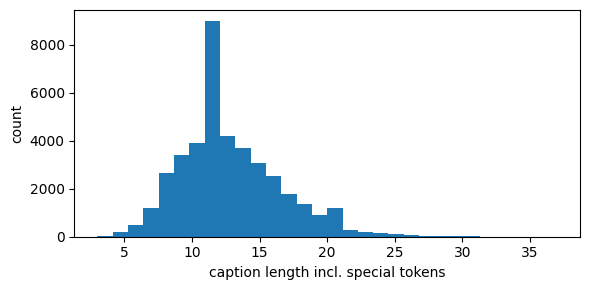

In [12]:
if captions and word2idx:
    lengths = [len(encode_caption(cap, word2idx, max_len=None)) for caps in captions.values() for cap in caps]
    print("Caption length min/mean/p95/max:", int(np.min(lengths)), float(np.mean(lengths)), int(np.percentile(lengths, 95)), int(np.max(lengths)))
    plt.figure(figsize=(6, 3))
    plt.hist(lengths, bins=30)
    plt.xlabel("caption length incl. special tokens")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

## 3. Dataset Builder Smoke Test

In [13]:
if has_required_files():
    splits = load_splits(SPLITS_JSON)
    features = load_features(str(FEATURES_PATH))
    train_names = [name for name in splits["train"] if name in captions and name in features][:8]
    ds_preview = build_dataset(
        train_names,
        captions,
        features,
        word2idx,
        max_seq_len=MAX_SEQ_LEN,
        batch_size=4,
        shuffle=False,
        injection_method="pre",
    )
    for (img_batch, tok_batch), y_batch in ds_preview.take(1):
        print("image_features", img_batch.shape)
        print("caption_tokens", tok_batch.shape)
        print("target", y_batch.shape)
else:
    splits, features = {"train": [], "val": [], "test": []}, {}

image_features (4, 2048)
caption_tokens (4, 34)
target (4, 35)


## 4. RNN Decoder Training

In [14]:
def make_config(decoder_type, n_layers, hidden_size, injection_method="pre"):
    return DecoderExperimentConfig(
        decoder_type=decoder_type,
        n_layers=n_layers,
        hidden_size=hidden_size,
        embed_dim=EMBED_DIM,
        max_seq_len=MAX_SEQ_LEN,
        feature_dim=FEATURE_DIM,
        learning_rate=LEARNING_RATE,
        injection_method=injection_method,
    )


def decoder_configs(decoder_type, injection_method="pre"):
    return [make_config(decoder_type, **variation, injection_method=injection_method) for variation in VARIATIONS]

rnn_configs = decoder_configs("rnn")
[c.experiment_id for c in rnn_configs]

['rnn_pre_l1_h128_e256_m35',
 'rnn_pre_l1_h256_e256_m35',
 'rnn_pre_l2_h128_e256_m35',
 'rnn_pre_l2_h256_e256_m35',
 'rnn_pre_l3_h128_e256_m35',
 'rnn_pre_l3_h256_e256_m35']

In [15]:
def train_grid(configs, run_flag):
    trained, skipped = [], []
    if not run_flag:
        print("Training flag False; hanya cek artefak yang sudah ada.")
    if not has_required_files():
        return trained, skipped

    splits = load_splits(SPLITS_JSON)
    features = load_features(str(FEATURES_PATH))
    for config in configs:
        exp_dir = MODELS_DIR / config.experiment_id
        if (exp_dir / "model.keras").exists() and not FORCE_RETRAIN:
            skipped.append(config.experiment_id)
            continue
        if run_flag:
            print("Training", config.experiment_id)
            train_one(config, captions, splits, features, word2idx, MODELS_DIR, BATCH_SIZE, EPOCHS, SEED)
            trained.append(config.experiment_id)
        else:
            skipped.append(config.experiment_id)
    return trained, skipped

In [16]:
rnn_trained, rnn_skipped = train_grid(rnn_configs, RUN_TRAIN_RNN)
{"trained": rnn_trained, "available_or_skipped": rnn_skipped}

Training rnn_pre_l1_h128_e256_m35
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 5.6395 - masked_accuracy: 0.1685 - val_loss: 4.6391 - val_masked_accuracy: 0.2322
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 4.4295 - masked_accuracy: 0.2419 - val_loss: 4.4390 - val_masked_accuracy: 0.2444
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 4.2100 - masked_accuracy: 0.2538 - val_loss: 4.3031 - val_masked_accuracy: 0.2571
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 4.0177 - masked_accuracy: 0.2720 - val_loss: 4.2335 - val_masked_accuracy: 0.2609
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 3.8959 - masked_accuracy: 0.2786 - val_loss: 4.1896 - val_masked_accuracy: 0.2634
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 3.7926 - masked_accuracy: 0.2855 - val_loss: 4.1579 - val_masked_accuracy: 0.2670
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 3.7055 - masked_accuracy: 0.2924 - val_loss: 4

{'trained': ['rnn_pre_l1_h128_e256_m35',
  'rnn_pre_l1_h256_e256_m35',
  'rnn_pre_l2_h128_e256_m35',
  'rnn_pre_l2_h256_e256_m35',
  'rnn_pre_l3_h128_e256_m35',
  'rnn_pre_l3_h256_e256_m35'],
 'available_or_skipped': []}

In [17]:
def history_summary(experiment_id):
    exp_dir = MODELS_DIR / experiment_id
    history = read_json(exp_dir / "history.json", {})
    metrics = read_json(exp_dir / "metrics.json", {})
    config = read_json(exp_dir / "config.json", {})
    if not history and not metrics:
        return None
    return {
        "experiment": experiment_id,
        "decoder_type": config.get("decoder_type"),
        "injection": config.get("injection_method"),
        "layers": config.get("n_layers"),
        "hidden": config.get("hidden_size"),
        "loss": (history.get("loss") or [None])[-1],
        "val_loss": (history.get("val_loss") or [None])[-1],
        "param_count": metrics.get("param_count"),
    }


def summarize_decoder(decoder_type, injection="pre"):
    rows = []
    for config in decoder_configs(decoder_type, injection):
        row = history_summary(config.experiment_id)
        if row:
            rows.append(row)
    rows.sort(key=lambda r: float("inf") if r["val_loss"] is None else r["val_loss"])
    return rows

rnn_summary = summarize_decoder("rnn")
rnn_summary

[{'experiment': 'rnn_pre_l1_h128_e256_m35',
  'decoder_type': 'rnn',
  'injection': 'pre',
  'layers': 1,
  'hidden': 128,
  'loss': 2.9145896434783936,
  'val_loss': 4.272775173187256,
  'param_count': 3532164},
 {'experiment': 'rnn_pre_l2_h128_e256_m35',
  'decoder_type': 'rnn',
  'injection': 'pre',
  'layers': 2,
  'hidden': 128,
  'loss': 2.903830051422119,
  'val_loss': 4.27979040145874,
  'param_count': 3565060},
 {'experiment': 'rnn_pre_l3_h128_e256_m35',
  'decoder_type': 'rnn',
  'injection': 'pre',
  'layers': 3,
  'hidden': 128,
  'loss': 3.02730393409729,
  'val_loss': 4.2800726890563965,
  'param_count': 3597956},
 {'experiment': 'rnn_pre_l3_h256_e256_m35',
  'decoder_type': 'rnn',
  'injection': 'pre',
  'layers': 3,
  'hidden': 256,
  'loss': 2.7082419395446777,
  'val_loss': 4.333334445953369,
  'param_count': 4860420},
 {'experiment': 'rnn_pre_l2_h256_e256_m35',
  'decoder_type': 'rnn',
  'injection': 'pre',
  'layers': 2,
  'hidden': 256,
  'loss': 2.5527703762054443

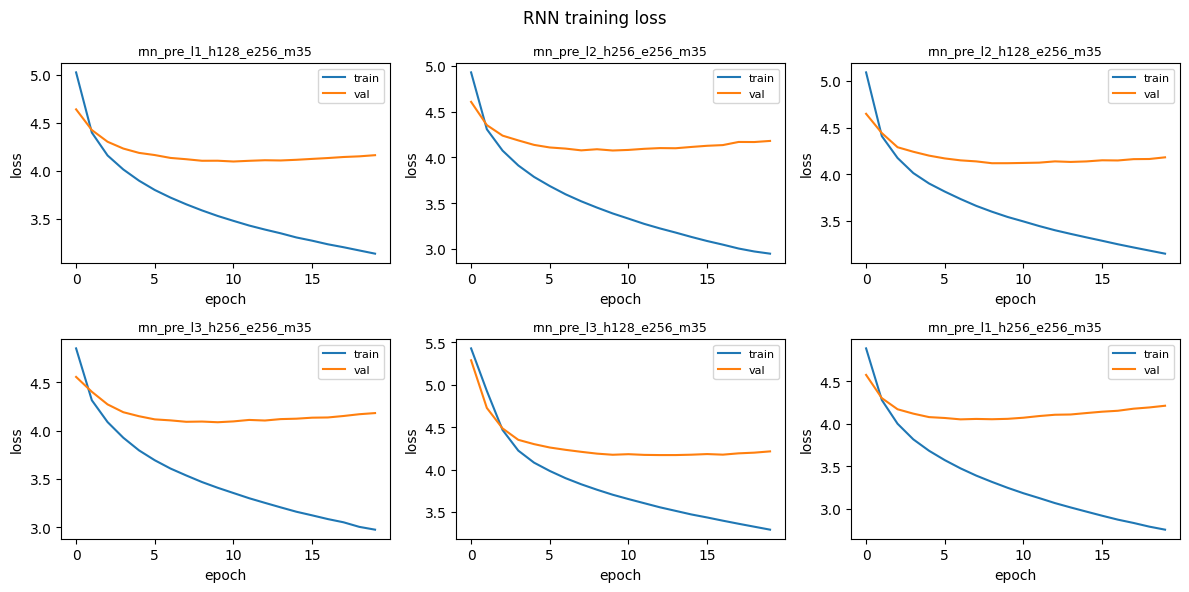

In [18]:
def plot_histories(rows, title, output_path=None):
    if not rows:
        print("Belum ada history untuk diplot.")
        return
    cols = 3
    rows_n = int(np.ceil(len(rows) / cols))
    plt.figure(figsize=(cols * 4, rows_n * 3))
    for i, row in enumerate(rows, start=1):
        hist = read_json(MODELS_DIR / row["experiment"] / "history.json", {})
        ax = plt.subplot(rows_n, cols, i)
        ax.plot(hist.get("loss", []), label="train")
        ax.plot(hist.get("val_loss", []), label="val")
        ax.set_title(row["experiment"], fontsize=9)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend(fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    plt.show()

plot_histories(rnn_summary, "RNN training loss", PLOTS_DIR / "rnn_loss_curves.png")

## 5. LSTM Decoder Training

In [19]:
lstm_configs = decoder_configs("lstm")
[c.experiment_id for c in lstm_configs]

['lstm_pre_l1_h128_e256_m35',
 'lstm_pre_l1_h256_e256_m35',
 'lstm_pre_l2_h128_e256_m35',
 'lstm_pre_l2_h256_e256_m35',
 'lstm_pre_l3_h128_e256_m35',
 'lstm_pre_l3_h256_e256_m35']

In [20]:
lstm_trained, lstm_skipped = train_grid(lstm_configs, RUN_TRAIN_LSTM)
{"trained": lstm_trained, "available_or_skipped": lstm_skipped}

Training lstm_pre_l1_h128_e256_m35
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - loss: 5.8289 - masked_accuracy: 0.1545 - val_loss: 4.7810 - val_masked_accuracy: 0.2232
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 4.5624 - masked_accuracy: 0.2321 - val_loss: 4.5255 - val_masked_accuracy: 0.2378
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 4.2918 - masked_accuracy: 0.2514 - val_loss: 4.3453 - val_masked_accuracy: 0.2536
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 4.0848 - masked_accuracy: 0.2671 - val_loss: 4.2625 - val_masked_accuracy: 0.2591
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 3.9617 - masked_accuracy: 0.2750 - val_loss: 4.1970 - val_masked_accuracy: 0.2628
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 3.8520 - masked_accuracy: 0.2828 - val_loss: 4.1506 - val_masked_accuracy: 0.2682
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 3.7556 - masked_accuracy: 0.2899 - val_

{'trained': ['lstm_pre_l1_h128_e256_m35',
  'lstm_pre_l1_h256_e256_m35',
  'lstm_pre_l2_h128_e256_m35',
  'lstm_pre_l2_h256_e256_m35',
  'lstm_pre_l3_h128_e256_m35',
  'lstm_pre_l3_h256_e256_m35'],
 'available_or_skipped': []}

In [21]:
lstm_summary = summarize_decoder("lstm")
lstm_summary

[{'experiment': 'lstm_pre_l2_h128_e256_m35',
  'decoder_type': 'lstm',
  'injection': 'pre',
  'layers': 2,
  'hidden': 128,
  'loss': 2.8646082878112793,
  'val_loss': 4.124604225158691,
  'param_count': 3811588},
 {'experiment': 'lstm_pre_l3_h128_e256_m35',
  'decoder_type': 'lstm',
  'injection': 'pre',
  'layers': 3,
  'hidden': 128,
  'loss': 3.1197032928466797,
  'val_loss': 4.150559902191162,
  'param_count': 3943172},
 {'experiment': 'lstm_pre_l1_h128_e256_m35',
  'decoder_type': 'lstm',
  'injection': 'pre',
  'layers': 1,
  'hidden': 128,
  'loss': 2.7896108627319336,
  'val_loss': 4.165531635284424,
  'param_count': 3680004},
 {'experiment': 'lstm_pre_l2_h256_e256_m35',
  'decoder_type': 'lstm',
  'injection': 'pre',
  'layers': 2,
  'hidden': 256,
  'loss': 2.37093448638916,
  'val_loss': 4.222012042999268,
  'param_count': 5517060},
 {'experiment': 'lstm_pre_l3_h256_e256_m35',
  'decoder_type': 'lstm',
  'injection': 'pre',
  'layers': 3,
  'hidden': 256,
  'loss': 2.66821

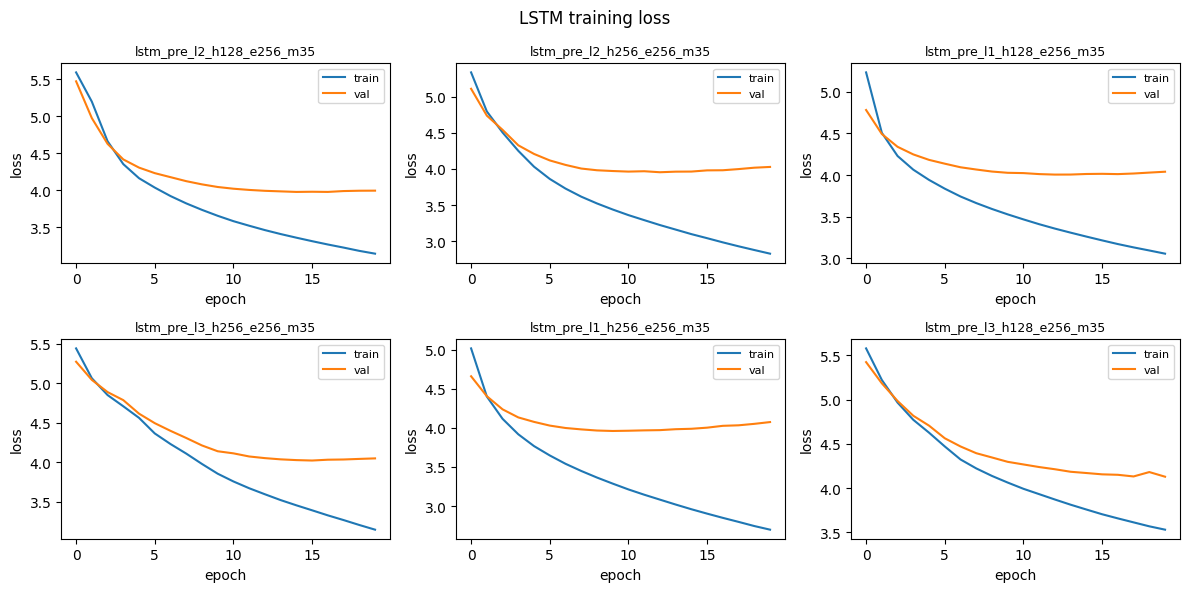

In [22]:
plot_histories(lstm_summary, "LSTM training loss", PLOTS_DIR / "lstm_loss_curves.png")

## 6. Select Best Models

In [23]:
def select_best(rows):
    if not rows:
        return None
    return min(rows, key=lambda r: float("inf") if r["val_loss"] is None else r["val_loss"])

best_rnn = select_best(rnn_summary)
best_lstm = select_best(lstm_summary)
best_rnn, best_lstm

({'experiment': 'rnn_pre_l1_h128_e256_m35',
  'decoder_type': 'rnn',
  'injection': 'pre',
  'layers': 1,
  'hidden': 128,
  'loss': 2.9145896434783936,
  'val_loss': 4.272775173187256,
  'param_count': 3532164},
 {'experiment': 'lstm_pre_l2_h128_e256_m35',
  'decoder_type': 'lstm',
  'injection': 'pre',
  'layers': 2,
  'hidden': 128,
  'loss': 2.8646082878112793,
  'val_loss': 4.124604225158691,
  'param_count': 3811588})

In [ ]:
def load_keras_caption_model(experiment_id):
    model_path = MODELS_DIR / experiment_id / "model.keras"
    if not model_path.exists():
        raise FileNotFoundError(model_path)
    return tf.keras.models.load_model(model_path, compile=False)


def load_scratch_caption_model(experiment_id, decoder_type, injection="pre"):
    keras_model = load_keras_caption_model(experiment_id)
    scratch = CaptionModel(decoder_type=decoder_type, injection_method=injection)
    scratch.load_from_keras(keras_model, word2idx, idx2word)
    return scratch

## 7. Evaluation Helpers

In [25]:
def filtered_eval_names(split="test", n=N_EVAL):
    if not has_required_files():
        return []
    splits = load_splits(SPLITS_JSON)
    feats = load_features(str(FEATURES_PATH))
    names = [name for name in splits[split] if name in captions and name in feats]
    return names[:n] if n else names


def evaluate_with_time(model, decoder_type, mode, image_names, max_len=MAX_SEQ_LEN, decoding="greedy", beam_size=3, injection="pre"):
    feats = load_features(str(FEATURES_PATH))
    start = time.perf_counter()
    result = evaluate(
        model=model,
        captions=captions,
        image_names=image_names,
        features=feats,
        word2idx=word2idx,
        idx2word=idx2word,
        decoder_type=decoder_type,
        max_len=max_len,
        mode=mode,
        seed=SEED,
        decoding=decoding,
        beam_size=beam_size,
        length_penalty=0.7,
        injection_method=injection,
    )
    elapsed = time.perf_counter() - start
    result["metrics"]["total_time_s"] = elapsed
    result["metrics"]["avg_time_ms"] = 1000 * elapsed / max(len(result["details"]), 1)
    result["metrics"]["decoding"] = decoding
    result["metrics"]["beam_size"] = beam_size if decoding == "beam" else None
    result["metrics"]["injection"] = injection
    return result

In [26]:
def evaluate_experiment(experiment_id, decoder_type, image_names, modes=("keras", "scratch"), decoding="greedy", beam_size=3, injection="pre"):
    out = {}
    if "keras" in modes:
        keras_model = load_keras_caption_model(experiment_id)
        out["keras"] = evaluate_with_time(keras_model, decoder_type, "keras", image_names, decoding=decoding, beam_size=beam_size, injection=injection)
    if "scratch" in modes:
        scratch_model = load_scratch_caption_model(experiment_id, decoder_type, injection=injection)
        out["scratch"] = evaluate_with_time(scratch_model, decoder_type, "scratch", image_names, decoding=decoding, beam_size=beam_size, injection=injection)
    return out

## 8. RNN Evaluation: Keras vs Scratch

In [27]:
eval_names = filtered_eval_names("test", N_EVAL)
print("Eval samples:", len(eval_names))

rnn_best_eval = {}
if best_rnn and eval_names and RUN_FULL_EVAL:
    rnn_best_eval = evaluate_experiment(best_rnn["experiment"], "rnn", eval_names, modes=("keras", "scratch"))
    write_json(EVAL_DIR / "best_rnn_eval.json", rnn_best_eval)
else:
    rnn_best_eval = read_json(EVAL_DIR / "best_rnn_eval.json", {})

{k: v.get("metrics", {}) for k, v in rnn_best_eval.items()}

Eval samples: 50


{'keras': {'bleu4': 0.02465955154719506,
  'meteor': 0.2380732930611008,
  'samples': 50,
  'mode': 'keras',
  'decoder_type': 'rnn',
  'total_time_s': 54.572698311999375,
  'avg_time_ms': 1091.4539662399875,
  'decoding': 'greedy',
  'beam_size': None,
  'injection': 'pre'},
 'scratch': {'bleu4': 4.1812638249131085e-06,
  'meteor': 0.18490909406063,
  'samples': 50,
  'mode': 'scratch',
  'decoder_type': 'rnn',
  'total_time_s': 0.10700881499997195,
  'avg_time_ms': 2.140176299999439,
  'decoding': 'greedy',
  'beam_size': None,
  'injection': 'pre'}}

## 9. LSTM Evaluation: Keras vs Scratch

In [28]:
lstm_best_eval = {}
if best_lstm and eval_names and RUN_FULL_EVAL:
    lstm_best_eval = evaluate_experiment(best_lstm["experiment"], "lstm", eval_names, modes=("keras", "scratch"))
    write_json(EVAL_DIR / "best_lstm_eval.json", lstm_best_eval)
else:
    lstm_best_eval = read_json(EVAL_DIR / "best_lstm_eval.json", {})

{k: v.get("metrics", {}) for k, v in lstm_best_eval.items()}

/kaggle/working/SpreiElsa/src/rnn-lstm/lstm.py:5: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500.0, 500.0)))


{'keras': {'bleu4': 0.034568179378248354,
  'meteor': 0.26430036005609187,
  'samples': 50,
  'mode': 'keras',
  'decoder_type': 'lstm',
  'total_time_s': 65.6064454059997,
  'avg_time_ms': 1312.1289081199939,
  'decoding': 'greedy',
  'beam_size': None,
  'injection': 'pre'},
 'scratch': {'bleu4': 6.997116337722279e-06,
  'meteor': 0.23486324876385406,
  'samples': 50,
  'mode': 'scratch',
  'decoder_type': 'lstm',
  'total_time_s': 0.6398830520001866,
  'avg_time_ms': 12.797661040003732,
  'decoding': 'greedy',
  'beam_size': None,
  'injection': 'pre'}}

## 10. Evaluate All Variations

In [29]:
def evaluate_all_variations(decoder_type, rows, max_samples=N_EVAL):
    names = filtered_eval_names("test", max_samples)
    results = {}
    for row in rows:
        exp_id = row["experiment"]
        model_path = MODELS_DIR / exp_id / "model.keras"
        if not model_path.exists():
            continue
        print("Evaluating", exp_id)
        keras_model = load_keras_caption_model(exp_id)
        res = evaluate_with_time(keras_model, decoder_type, "keras", names)
        results[exp_id] = {
            "summary": res["metrics"],
            "results": res["details"],
            "num_layers": row["layers"],
            "hidden_units": row["hidden"],
        }
    return results

if RUN_FULL_EVAL:
    rnn_variation_results = evaluate_all_variations("rnn", rnn_summary)
    lstm_variation_results = evaluate_all_variations("lstm", lstm_summary)
    write_json(EVAL_DIR / "rnn_variations.json", rnn_variation_results)
    write_json(EVAL_DIR / "lstm_variations.json", lstm_variation_results)
else:
    rnn_variation_results = read_json(EVAL_DIR / "rnn_variations.json", {})
    lstm_variation_results = read_json(EVAL_DIR / "lstm_variations.json", {})

len(rnn_variation_results), len(lstm_variation_results)

Evaluating rnn_pre_l1_h128_e256_m35
Evaluating rnn_pre_l2_h128_e256_m35
Evaluating rnn_pre_l3_h128_e256_m35
Evaluating rnn_pre_l3_h256_e256_m35
Evaluating rnn_pre_l2_h256_e256_m35
Evaluating rnn_pre_l1_h256_e256_m35
Evaluating lstm_pre_l2_h128_e256_m35
Evaluating lstm_pre_l3_h128_e256_m35
Evaluating lstm_pre_l1_h128_e256_m35
Evaluating lstm_pre_l2_h256_e256_m35
Evaluating lstm_pre_l3_h256_e256_m35
Evaluating lstm_pre_l1_h256_e256_m35


(6, 6)

In [30]:
def variation_table(results):
    rows = []
    for name, payload in results.items():
        summary = payload.get("summary", {})
        rows.append({
            "experiment": name,
            "layers": payload.get("num_layers"),
            "hidden": payload.get("hidden_units"),
            "bleu4": summary.get("bleu4"),
            "meteor": summary.get("meteor"),
            "avg_time_ms": summary.get("avg_time_ms"),
        })
    rows.sort(key=lambda r: r.get("bleu4") or -1, reverse=True)
    return rows

rnn_variation_table = variation_table(rnn_variation_results)
lstm_variation_table = variation_table(lstm_variation_results)
rnn_variation_table[:3], lstm_variation_table[:3]

([{'experiment': 'rnn_pre_l2_h256_e256_m35',
   'layers': 2,
   'hidden': 256,
   'bleu4': 0.031869726419483844,
   'meteor': 0.25159844325457675,
   'avg_time_ms': 1046.7419884800074},
  {'experiment': 'rnn_pre_l3_h128_e256_m35',
   'layers': 3,
   'hidden': 128,
   'bleu4': 0.030446437128540085,
   'meteor': 0.24877324087674965,
   'avg_time_ms': 1175.4985239399866},
  {'experiment': 'rnn_pre_l1_h128_e256_m35',
   'layers': 1,
   'hidden': 128,
   'bleu4': 0.02465955154719506,
   'meteor': 0.2380732930611008,
   'avg_time_ms': 1181.0302548599975}],
 [{'experiment': 'lstm_pre_l1_h128_e256_m35',
   'layers': 1,
   'hidden': 128,
   'bleu4': 0.04026830839205254,
   'meteor': 0.2519606305768816,
   'avg_time_ms': 1354.4426107400068},
  {'experiment': 'lstm_pre_l2_h128_e256_m35',
   'layers': 2,
   'hidden': 128,
   'bleu4': 0.034568179378248354,
   'meteor': 0.26430036005609187,
   'avg_time_ms': 1311.1586480000003},
  {'experiment': 'lstm_pre_l1_h256_e256_m35',
   'layers': 1,
   'hidde

In [31]:
def select_best_bleu(variation_table_rows, summary_rows):
    """Pick model with highest BLEU-4; fall back to val_loss selection."""
    if not variation_table_rows:
        return select_best(summary_rows)
    best_row = variation_table_rows[0] 
    exp_id = best_row["experiment"]
    for row in summary_rows:
        if row["experiment"] == exp_id:
            return row
    return select_best(summary_rows)

best_rnn  = select_best_bleu(rnn_variation_table,  rnn_summary)
best_lstm = select_best_bleu(lstm_variation_table, lstm_summary)
print("Best RNN  (by BLEU-4):", best_rnn)
print("Best LSTM (by BLEU-4):", best_lstm)


Best RNN  (by BLEU-4): {'experiment': 'rnn_pre_l2_h256_e256_m35', 'decoder_type': 'rnn', 'injection': 'pre', 'layers': 2, 'hidden': 256, 'loss': 2.5527703762054443, 'val_loss': 4.370693206787109, 'param_count': 4729092}
Best LSTM (by BLEU-4): {'experiment': 'lstm_pre_l1_h128_e256_m35', 'decoder_type': 'lstm', 'injection': 'pre', 'layers': 1, 'hidden': 128, 'loss': 2.7896108627319336, 'val_loss': 4.165531635284424, 'param_count': 3680004}


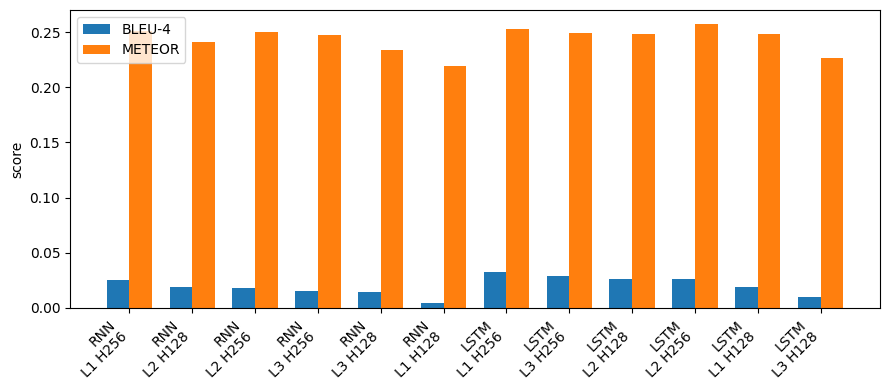

In [32]:
def plot_variation_bleu(rnn_rows, lstm_rows):
    rows = [("RNN", r) for r in rnn_rows] + [("LSTM", r) for r in lstm_rows]
    if not rows:
        print("Belum ada hasil variasi untuk diplot.")
        return
    labels = [f"{kind}\nL{r['layers']} H{r['hidden']}" for kind, r in rows]
    bleu = [r.get("bleu4") or 0 for _, r in rows]
    meteor = [r.get("meteor") or 0 for _, r in rows]
    x = np.arange(len(rows))
    plt.figure(figsize=(max(8, len(rows) * 0.75), 4))
    plt.bar(x - 0.18, bleu, width=0.36, label="BLEU-4")
    plt.bar(x + 0.18, meteor, width=0.36, label="METEOR")
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "analysis_variations_bleu_meteor.png")
    plt.show()

plot_variation_bleu(rnn_variation_table, lstm_variation_table)

## 11. Qualitative Analysis

In [33]:
def detail_by_image(result):
    details = result.get("details", []) if result else []
    return {row["image"]: row for row in details}

rnn_details = detail_by_image((rnn_best_eval or {}).get("keras", {}))
lstm_details = detail_by_image((lstm_best_eval or {}).get("keras", {}))
common_images = sorted(set(rnn_details) & set(lstm_details))
print("Common evaluated images:", len(common_images))

Common evaluated images: 50


In [34]:
def choose_qualitative_examples(common, k=10):
    scored = []
    for image in common:
        rb = rnn_details[image].get("bleu4", 0)
        lb = lstm_details[image].get("bleu4", 0)
        scored.append((image, (rb + lb) / 2))
    if not scored:
        return []
    scored.sort(key=lambda item: item[1])
    picks = []
    for frac in np.linspace(0, 1, k):
        idx = int(round(frac * (len(scored) - 1)))
        picks.append(scored[idx][0])
    return list(dict.fromkeys(picks))

qual_images = choose_qualitative_examples(common_images, 10)
qual_rows = []
for image in qual_images:
    qual_rows.append({
        "image": image,
        "rnn_bleu4": rnn_details[image].get("bleu4"),
        "lstm_bleu4": lstm_details[image].get("bleu4"),
        "rnn_caption": rnn_details[image].get("candidate"),
        "lstm_caption": lstm_details[image].get("candidate"),
        "ground_truth": rnn_details[image].get("references", [])[:2],
    })
qual_rows

[{'image': '3721799573_2f470950e0.jpg',
  'rnn_bleu4': 9.55442792204367e-08,
  'lstm_bleu4': 1.0000000000000007e-09,
  'rnn_caption': 'a woman in a black dress and a hat jacket a a',
  'lstm_caption': 'a woman in a red shirt is a a in in',
  'ground_truth': ['There are two ladies embracing and posing shown here .',
   'Two girlfriends smiling .']},
 {'image': '3725177385_62d5e13634.jpg',
  'rnn_bleu4': 1.4953487812212206e-07,
  'lstm_bleu4': 1.2850858522641766e-07,
  'rnn_caption': 'a man car a a on with street',
  'lstm_caption': 'a man is a a on on fire back a the',
  'ground_truth': ['A bunch of vintage cars are parked in a lot .',
   'An antique car that is yellow is shown lined up with other cars .']},
 {'image': '3726590391_bc6e729bb6.jpg',
  'rnn_bleu4': 8.19544321298924e-08,
  'lstm_bleu4': 1.3068378352572806e-05,
  'rnn_caption': 'a young in in blows clothes',
  'lstm_caption': 'a woman girl a a and on girl a a shirt is a a in in',
  'ground_truth': ['An elderly woman is cryin

## 12. Analysis 5a: Layers and Hidden State

In [35]:
def aggregate_by(rows, key):
    groups = {}
    for row in rows:
        groups.setdefault(row[key], []).append(row)
    return {
        k: {
            "mean_bleu4": float(np.mean([r.get("bleu4") or 0 for r in v])),
            "mean_meteor": float(np.mean([r.get("meteor") or 0 for r in v])),
            "mean_time_ms": float(np.mean([r.get("avg_time_ms") or 0 for r in v])),
        }
        for k, v in groups.items()
    }

analysis_5a = {
    "rnn_by_layers": aggregate_by(rnn_variation_table, "layers"),
    "rnn_by_hidden": aggregate_by(rnn_variation_table, "hidden"),
    "lstm_by_layers": aggregate_by(lstm_variation_table, "layers"),
    "lstm_by_hidden": aggregate_by(lstm_variation_table, "hidden"),
}
analysis_5a

{'rnn_by_layers': {2: {'mean_bleu4': 0.020812604409079866,
   'mean_meteor': 0.24317429169499744,
   'mean_time_ms': 1091.793023170003},
  3: {'mean_bleu4': 0.01874298708985728,
   'mean_meteor': 0.24583566702357723,
   'mean_time_ms': 1161.6748953299975},
  1: {'mean_bleu4': 0.019710505706922496,
   'mean_meteor': 0.24550317853778258,
   'mean_time_ms': 1142.404142330006}},
 'rnn_by_hidden': {256: {'mean_bleu4': 0.017890241112436086,
   'mean_meteor': 0.24914320014648195,
   'mean_time_ms': 1099.45709500001},
  128: {'mean_bleu4': 0.02162049035813701,
   'mean_meteor': 0.24053222469108956,
   'mean_time_ms': 1164.4576122199942}},
 'lstm_by_layers': {1: {'mean_bleu4': 0.03686285850901448,
   'mean_meteor': 0.2684805087609159,
   'mean_time_ms': 1173.3154526900034},
  2: {'mean_bleu4': 0.03310382421835352,
   'mean_meteor': 0.2641313707197186,
   'mean_time_ms': 1248.6918480800068},
  3: {'mean_bleu4': 0.020732517572649177,
   'mean_meteor': 0.2505573290709584,
   'mean_time_ms': 1141.4

Catatan analisis: isi kesimpulan akhir setelah eksperimen dijalankan. Umumnya hidden state lebih besar memberi kapasitas representasi lebih baik tetapi inference lebih lambat; layer tambahan bisa membantu konteks sekuensial, namun mudah overfit pada Flickr8k jika epoch/data terbatas.

## 13. Analysis 5b: Keras vs Scratch

In [36]:
def keras_scratch_comparison(eval_payload, label):
    if not eval_payload:
        return None
    k = eval_payload.get("keras", {}).get("metrics", {})
    s = eval_payload.get("scratch", {}).get("metrics", {})
    return {
        "decoder": label,
        "keras_bleu4": k.get("bleu4"),
        "scratch_bleu4": s.get("bleu4"),
        "keras_meteor": k.get("meteor"),
        "scratch_meteor": s.get("meteor"),
        "keras_avg_time_ms": k.get("avg_time_ms"),
        "scratch_avg_time_ms": s.get("avg_time_ms"),
    }

comparison_keras_scratch = [
    keras_scratch_comparison(rnn_best_eval, "RNN"),
    keras_scratch_comparison(lstm_best_eval, "LSTM"),
]
[row for row in comparison_keras_scratch if row]

[{'decoder': 'RNN',
  'keras_bleu4': 0.02465955154719506,
  'scratch_bleu4': 4.1812638249131085e-06,
  'keras_meteor': 0.2380732930611008,
  'scratch_meteor': 0.18490909406063,
  'keras_avg_time_ms': 1091.4539662399875,
  'scratch_avg_time_ms': 2.140176299999439},
 {'decoder': 'LSTM',
  'keras_bleu4': 0.034568179378248354,
  'scratch_bleu4': 6.997116337722279e-06,
  'keras_meteor': 0.26430036005609187,
  'scratch_meteor': 0.23486324876385406,
  'keras_avg_time_ms': 1312.1289081199939,
  'scratch_avg_time_ms': 12.797661040003732}]

Catatan analisis: scratch memakai operasi NumPy dan loop Python sehingga biasanya lebih lambat dari Keras/TensorFlow. Score seharusnya dekat jika bobot dan urutan operasi sama; selisih kecil dapat muncul dari detail numerik, masking, atau perbedaan decoding step.

## 14. Analysis 5c: RNN vs LSTM

In [37]:
def compare_rnn_lstm_details():
    rows = []
    for image in common_images:
        r = rnn_details[image]
        l = lstm_details[image]
        rows.append({
            "image": image,
            "rnn_bleu4": r.get("bleu4", 0),
            "lstm_bleu4": l.get("bleu4", 0),
            "rnn_meteor": r.get("meteor", 0),
            "lstm_meteor": l.get("meteor", 0),
        })
    return rows

rnn_lstm_rows = compare_rnn_lstm_details()
rnn_lstm_summary = {
    "n_common": len(rnn_lstm_rows),
    "rnn_bleu4": float(np.mean([r["rnn_bleu4"] for r in rnn_lstm_rows])) if rnn_lstm_rows else None,
    "lstm_bleu4": float(np.mean([r["lstm_bleu4"] for r in rnn_lstm_rows])) if rnn_lstm_rows else None,
    "rnn_meteor": float(np.mean([r["rnn_meteor"] for r in rnn_lstm_rows])) if rnn_lstm_rows else None,
    "lstm_meteor": float(np.mean([r["lstm_meteor"] for r in rnn_lstm_rows])) if rnn_lstm_rows else None,
}
rnn_lstm_summary

{'n_common': 50,
 'rnn_bleu4': 0.02465955154719506,
 'lstm_bleu4': 0.034568179378248354,
 'rnn_meteor': 0.2380732930611008,
 'lstm_meteor': 0.26430036005609187}

Catatan analisis: LSTM biasanya lebih stabil untuk caption karena gate input/forget/output membantu mempertahankan informasi jangka panjang dan mengurangi vanishing gradient. RNN sederhana lebih ringan, tetapi konteks awal caption cenderung lebih cepat hilang pada sekuens yang panjang.

## 15. Max Caption Length Study

In [38]:
def best_overall_for_length_study():
    candidates = []
    for label, best, payload in [("rnn", best_rnn, rnn_best_eval), ("lstm", best_lstm, lstm_best_eval)]:
        metrics = (payload or {}).get("keras", {}).get("metrics", {})
        if best and metrics:
            candidates.append((label, best["experiment"], metrics.get("bleu4") or 0, metrics.get("avg_time_ms") or float("inf")))
    if not candidates:
        return None
    return max(candidates, key=lambda item: (item[2], -item[3]))

best_length_model = best_overall_for_length_study()
best_length_model

('lstm', 'lstm_pre_l1_h128_e256_m35', 0.034568179378248354, 1312.1289081199939)

In [39]:
caption_lengths = [15, 25, MAX_SEQ_LEN]
length_bleu_results = {}
if RUN_FULL_EVAL and best_length_model and eval_names:
    decoder_type, exp_id, _, _ = best_length_model
    model = load_keras_caption_model(exp_id)
    for length in caption_lengths:
        res = evaluate_with_time(model, decoder_type, "keras", eval_names, max_len=length)
        length_bleu_results[length] = res["metrics"]["bleu4"]
    write_json(EVAL_DIR / "caption_length_study.json", length_bleu_results)
else:
    length_bleu_results = read_json(EVAL_DIR / "caption_length_study.json", {})

length_bleu_results

{15: 0.0420224084408229, 25: 0.04026830854465227, 35: 0.04026830839205254}

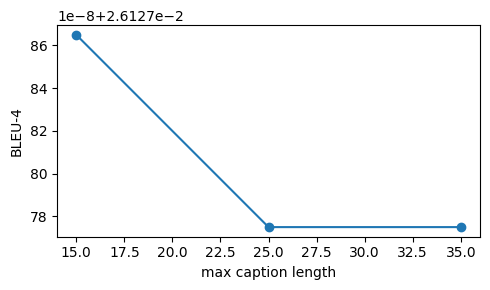

In [40]:
if length_bleu_results:
    xs = [int(k) for k in length_bleu_results.keys()]
    ys = [length_bleu_results[str(k)] if str(k) in length_bleu_results else length_bleu_results[k] for k in xs]
    plt.figure(figsize=(5, 3))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("max caption length")
    plt.ylabel("BLEU-4")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "caption_length_bleu.png")
    plt.show()

## 16. Bonus: Beam Search

In [41]:
def beam_comparison(best_row, decoder_type, beam_sizes=(1, 3, 5)):
    if not best_row or not eval_names:
        return {}
    exp_id = best_row["experiment"]
    scratch = load_scratch_caption_model(exp_id, decoder_type)
    rows = {}
    for beam in beam_sizes:
        decoding = "greedy" if beam == 1 else "beam"
        res = evaluate_with_time(scratch, decoder_type, "scratch", eval_names, decoding=decoding, beam_size=beam)
        rows[f"beam_{beam}"] = res["metrics"]
    return rows

if RUN_FULL_EVAL:
    rnn_beam = beam_comparison(best_rnn, "rnn")
    lstm_beam = beam_comparison(best_lstm, "lstm")
    write_json(EVAL_DIR / "beam_search.json", {"rnn": rnn_beam, "lstm": lstm_beam})
else:
    beam_payload = read_json(EVAL_DIR / "beam_search.json", {})
    rnn_beam = beam_payload.get("rnn", {})
    lstm_beam = beam_payload.get("lstm", {})

rnn_beam, lstm_beam

/kaggle/working/SpreiElsa/src/rnn-lstm/lstm.py:5: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500.0, 500.0)))


({'beam_1': {'bleu4': 4.5540295373082495e-06,
   'meteor': 0.18348826146107952,
   'samples': 50,
   'mode': 'scratch',
   'decoder_type': 'rnn',
   'total_time_s': 0.19043726000018069,
   'avg_time_ms': 3.8087452000036137,
   'decoding': 'greedy',
   'beam_size': None,
   'injection': 'pre'},
  'beam_3': {'bleu4': 4.760822938818384e-06,
   'meteor': 0.17465061437655374,
   'samples': 50,
   'mode': 'scratch',
   'decoder_type': 'rnn',
   'total_time_s': 0.7566486619998614,
   'avg_time_ms': 15.132973239997227,
   'decoding': 'beam',
   'beam_size': 3,
   'injection': 'pre'},
  'beam_5': {'bleu4': 3.62297664252899e-06,
   'meteor': 0.17171635338173882,
   'samples': 50,
   'mode': 'scratch',
   'decoder_type': 'rnn',
   'total_time_s': 1.351111325000602,
   'avg_time_ms': 27.02222650001204,
   'decoding': 'beam',
   'beam_size': 5,
   'injection': 'pre'}},
 {'beam_1': {'bleu4': 4.176714857771066e-06,
   'meteor': 0.18143699674074695,
   'samples': 50,
   'mode': 'scratch',
   'decoder_

In [42]:
def sample_beam_captions(best_row, decoder_type, image_name=None):
    if not best_row or not eval_names:
        return {}
    image_name = image_name or eval_names[0]
    feats = load_features(str(FEATURES_PATH))
    scratch = load_scratch_caption_model(best_row["experiment"], decoder_type)
    feat = np.asarray(feats[image_name], dtype=np.float32)
    return {
        "image": image_name,
        "greedy": scratch.generate_caption(feat, max_len=MAX_SEQ_LEN),
        "beam3": scratch.generate_caption_beam(feat, max_len=MAX_SEQ_LEN, beam_size=3),
        "beam5": scratch.generate_caption_beam(feat, max_len=MAX_SEQ_LEN, beam_size=5),
        "references": captions.get(image_name, []),
    }

sample_beam_rnn = sample_beam_captions(best_rnn, "rnn") if best_rnn and eval_names else {}
sample_beam_lstm = sample_beam_captions(best_lstm, "lstm") if best_lstm and eval_names else {}
sample_beam_rnn, sample_beam_lstm

({'image': '3717845800_ab45e255b8.jpg',
  'greedy': 'a and player the is the has ball his',
  'beam3': 'a and player the is the with other playing',
  'beam5': 'a and player the is the with other playing',
  'references': ['Four rugby players on the ground with two standing behind them .',
   'Members of two soccer teams struggle on the field to get the ball .',
   'Soccer players on the ground fighting for the ball .',
   'The rugby players in red are wrestling the player in yellow to the ground .',
   'Three members of the red team are in the grass with a member of the yellow team .']},
 {'image': '3717845800_ab45e255b8.jpg',
  'greedy': 'a player a and uniform in air to a ball a player a in',
  'beam3': 'a player a player a and uniform in air to the',
  'beam5': 'a player a and uniform in air to the',
  'references': ['Four rugby players on the ground with two standing behind them .',
   'Members of two soccer teams struggle on the field to get the ball .',
   'Soccer players on the

## 17. Bonus: Batch Inference from Scratch

In [43]:
def generate_captions_batch_scratch(model: CaptionModel, feature_batch: np.ndarray, max_len=MAX_SEQ_LEN):
    """True batch greedy decode matching single-image generate_caption (pre-inject).
    Feed sequence: [image] -> T0, [<start>] -> T1, [T0] -> T2, [T1] -> T3, ...
    """
    pad_idx   = model.word2idx["<pad>"]
    start_idx = model.word2idx["<start>"]
    end_idx   = model.word2idx["<end>"]
    batch     = feature_batch.shape[0]
    hs        = model.decoder.cells[0].hidden_size

    x_img = model.image_projection.forward(feature_batch.astype(np.float32))
    generated = [[] for _ in range(batch)]
    finished  = np.zeros(batch, dtype=bool)

    # Initialise states
    h = [np.zeros((batch, hs), dtype=np.float32) for _ in range(model.n_layers)]
    c = [np.zeros((batch, hs), dtype=np.float32) for _ in range(model.n_layers)]         if model.decoder_type == "lstm" else None

    def step(x):
        nonlocal h, c
        if model.decoder_type == "rnn":
            out, h = model.decoder.step(x, h)
            return out
        out, h, c = model.decoder.step(x, h, c)
        return out

    def predict(out):
        inp = np.concatenate([out, x_img], axis=-1) if model.injection_method == "init" else out
        return model.output_layer.forward(inp)

    if model.injection_method == "pre":
        # Step 0: image feature
        out    = step(x_img)
        tokens = np.argmax(predict(out), axis=-1).astype(np.int32)  # T0
        for i, tok in enumerate(tokens):
            if int(tok) in (end_idx, pad_idx):
                finished[i] = True
            else:
                generated[i].append(model.idx2word.get(int(tok), "<unk>"))

        # Feed sequence after image step: <start>, T0, T1, T2, ...
        to_feed   = np.full(batch, start_idx, dtype=np.int32)  # first: <start>
        prev_pred = tokens.copy()                               # then: T0, T1, ...

        for _ in range(max_len - 1):
            out       = step(model.embedding.forward(to_feed))
            new_tok   = np.argmax(predict(out), axis=-1).astype(np.int32)
            for i, tok in enumerate(new_tok):
                if not finished[i]:
                    if int(tok) in (end_idx, pad_idx):
                        finished[i] = True
                    else:
                        generated[i].append(model.idx2word.get(int(tok), "<unk>"))
            to_feed   = prev_pred       # delayed feed: T0 on iter 1, T1 on iter 2, ...
            prev_pred = new_tok
            if finished.all():
                break

    else:  # init-inject
        to_feed = np.full(batch, start_idx, dtype=np.int32)
        for _ in range(max_len):
            out     = step(model.embedding.forward(to_feed))
            to_feed = np.argmax(predict(out), axis=-1).astype(np.int32)
            for i, tok in enumerate(to_feed):
                if not finished[i]:
                    if int(tok) in (end_idx, pad_idx):
                        finished[i] = True
                    else:
                        generated[i].append(model.idx2word.get(int(tok), "<unk>"))
            if finished.all():
                break

    return [" ".join(words) for words in generated]

In [44]:
def batch_benchmark(best_row, decoder_type):
    if not best_row or not eval_names:
        return {}
    names = eval_names[:N_BATCH]
    feats = load_features(str(FEATURES_PATH))
    batch_feats = np.stack([feats[name] for name in names]).astype(np.float32)
    model = load_scratch_caption_model(best_row["experiment"], decoder_type)

    t0 = time.perf_counter()
    single_caps = [model.generate_caption(feat, MAX_SEQ_LEN) for feat in batch_feats]
    t_single = time.perf_counter() - t0

    t0 = time.perf_counter()
    batch_caps = generate_captions_batch_scratch(model, batch_feats, MAX_SEQ_LEN)
    t_batch = time.perf_counter() - t0

    return {
        "n": len(names),
        "single_total_s": t_single,
        "batch_total_s": t_batch,
        "single_avg_ms": 1000 * t_single / max(len(names), 1),
        "batch_avg_ms": 1000 * t_batch / max(len(names), 1),
        "match_rate": float(np.mean([a == b for a, b in zip(single_caps, batch_caps)])) if names else 0,
    }

batch_rnn = batch_benchmark(best_rnn, "rnn") if best_rnn and eval_names else {}
batch_lstm = batch_benchmark(best_lstm, "lstm") if best_lstm and eval_names else {}
batch_rnn, batch_lstm

({'n': 50,
  'single_total_s': 0.158876391999911,
  'batch_total_s': 0.11854458299967519,
  'single_avg_ms': 3.17752783999822,
  'batch_avg_ms': 2.3708916599935037,
  'match_rate': 1.0},
 {'n': 50,
  'single_total_s': 0.1261720630000127,
  'batch_total_s': 0.1187081890002446,
  'single_avg_ms': 2.5234412600002543,
  'batch_avg_ms': 2.374163780004892,
  'match_rate': 1.0})

## 18. Bonus: Init-Inject Architecture

In [45]:
def init_inject_configs_from_best():
    configs = []
    if best_rnn:
        configs.append(make_config("rnn", best_rnn["layers"], best_rnn["hidden"], injection_method="init"))
    if best_lstm:
        configs.append(make_config("lstm", best_lstm["layers"], best_lstm["hidden"], injection_method="init"))
    return configs

init_configs = init_inject_configs_from_best()
[c.experiment_id for c in init_configs]

['rnn_init_l2_h256_e256_m35', 'lstm_init_l1_h128_e256_m35']

In [46]:
init_trained, init_skipped = train_grid(init_configs, RUN_TRAIN_INIT_INJECT)
{"trained": init_trained, "available_or_skipped": init_skipped}

Training rnn_init_l2_h256_e256_m35
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - loss: 4.5527 - masked_accuracy: 0.2609 - val_loss: 3.4652 - val_masked_accuracy: 0.3491
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - loss: 2.9887 - masked_accuracy: 0.3847 - val_loss: 3.3230 - val_masked_accuracy: 0.3648
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 2.5887 - masked_accuracy: 0.4190 - val_loss: 3.2890 - val_masked_accuracy: 0.3709
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 2.3539 - masked_accuracy: 0.4444 - val_loss: 3.3165 - val_masked_accuracy: 0.3716
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 2.1871 - masked_accuracy: 0.4670 - val_loss: 3.3642 - val_masked_accuracy: 0.3730
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 2.0588 - masked_accuracy: 0.4848 - val_loss: 3.3793 - val_masked_accuracy: 0.3720
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 1.9482 - masked_accuracy: 0.5036 - val_

{'trained': ['rnn_init_l2_h256_e256_m35', 'lstm_init_l1_h128_e256_m35'],
 'available_or_skipped': []}

In [47]:
def compare_pre_vs_init(decoder_type, best_pre_row):
    if not best_pre_row or not eval_names:
        return {}
    init_config = make_config(decoder_type, best_pre_row["layers"], best_pre_row["hidden"], injection_method="init")
    init_path = MODELS_DIR / init_config.experiment_id / "model.keras"
    if not init_path.exists():
        return {"missing": str(init_path)}
    pre_model = load_keras_caption_model(best_pre_row["experiment"])
    init_model = load_keras_caption_model(init_config.experiment_id)
    return {
        "pre": evaluate_with_time(pre_model, decoder_type, "keras", eval_names, injection="pre")["metrics"],
        "init": evaluate_with_time(init_model, decoder_type, "keras", eval_names, injection="init")["metrics"],
    }

if RUN_FULL_EVAL:
    init_inject_results = {
        "rnn": compare_pre_vs_init("rnn", best_rnn),
        "lstm": compare_pre_vs_init("lstm", best_lstm),
    }
    write_json(EVAL_DIR / "init_inject_comparison.json", init_inject_results)
else:
    init_inject_results = read_json(EVAL_DIR / "init_inject_comparison.json", {})

init_inject_results

{'rnn': {'pre': {'bleu4': 0.031869726419483844,
   'meteor': 0.25159844325457675,
   'samples': 50,
   'mode': 'keras',
   'decoder_type': 'rnn',
   'total_time_s': 47.66256220300056,
   'avg_time_ms': 953.2512440600112,
   'decoding': 'greedy',
   'beam_size': None,
   'injection': 'pre'},
  'init': {'bleu4': 0.04890752527716976,
   'meteor': 0.2854751402354435,
   'samples': 50,
   'mode': 'keras',
   'decoder_type': 'rnn',
   'total_time_s': 62.15469935500005,
   'avg_time_ms': 1243.093987100001,
   'decoding': 'greedy',
   'beam_size': None,
   'injection': 'init'}},
 'lstm': {'pre': {'bleu4': 0.04026830839205254,
   'meteor': 0.2519606305768816,
   'samples': 50,
   'mode': 'keras',
   'decoder_type': 'lstm',
   'total_time_s': 62.24161036199985,
   'avg_time_ms': 1244.832207239997,
   'decoding': 'greedy',
   'beam_size': None,
   'injection': 'pre'},
  'init': {'bleu4': 0.056032758121396686,
   'meteor': 0.30613753983535125,
   'samples': 50,
   'mode': 'keras',
   'decoder_type

## 19. Bonus: Scratch Batch Sanity

In [48]:
def check_rnn_batch_sanity():
    rng = np.random.default_rng(0)
    batch, seq_len, input_dim, hidden = 2, 5, 4, 3
    x = rng.normal(size=(batch, seq_len, input_dim)).astype(np.float32)
    cell = SimpleRNNCell()
    cell.W_x = rng.normal(size=(input_dim, hidden)).astype(np.float32)
    cell.W_h = rng.normal(size=(hidden, hidden)).astype(np.float32)
    cell.b = rng.normal(size=(hidden,)).astype(np.float32)
    decoder = SimpleRNNDecoder([cell])
    outputs, h = decoder.forward(x)
    assert outputs.shape == (batch, seq_len, hidden), outputs.shape
    return outputs.shape


def check_lstm_batch_sanity():
    rng = np.random.default_rng(1)
    batch, seq_len, input_dim, hidden = 2, 6, 4, 3
    x = rng.normal(size=(batch, seq_len, input_dim)).astype(np.float32)
    cell = LSTMCell()
    cell.set_weights(
        rng.normal(size=(input_dim, 4 * hidden)).astype(np.float32),
        rng.normal(size=(hidden, 4 * hidden)).astype(np.float32),
        rng.normal(size=(4 * hidden,)).astype(np.float32),
    )
    decoder = LSTMDecoder([cell])
    outputs, h, c = decoder.forward(x)
    assert outputs.shape == (batch, seq_len, hidden), outputs.shape
    return outputs.shape

check_rnn_batch_sanity(), check_lstm_batch_sanity()

((2, 5, 3), (2, 6, 3))

## 20. Bonus: Backward Propagation Sanity

In [49]:
def relative_error(a, b, eps=1e-8):
    denom = np.maximum(eps, np.maximum(np.abs(a), np.abs(b)))
    return float(np.max(np.abs(a - b) / denom))


def rnn_cell_backward_sanity():
    rng = np.random.default_rng(0)
    x = rng.normal(size=(1, 3)).astype(np.float32)
    h_prev = rng.normal(size=(1, 2)).astype(np.float32)
    cell = SimpleRNNCell()
    cell.W_x = rng.normal(size=(3, 2)).astype(np.float32)
    cell.W_h = rng.normal(size=(2, 2)).astype(np.float32)
    cell.b = rng.normal(size=(2,)).astype(np.float32)
    h, cache = cell.forward_with_cache(x, h_prev)
    _, _, gWx, gWh, gb = cell.backward(np.ones_like(h), cache)
    return {"gWx": gWx.shape, "gWh": gWh.shape, "gb": gb.shape}


def lstm_cell_backward_sanity():
    rng = np.random.default_rng(1)
    x = rng.normal(size=(1, 3)).astype(np.float32)
    h_prev = rng.normal(size=(1, 2)).astype(np.float32)
    c_prev = rng.normal(size=(1, 2)).astype(np.float32)
    cell = LSTMCell()
    cell.set_weights(
        rng.normal(size=(3, 8)).astype(np.float32),
        rng.normal(size=(2, 8)).astype(np.float32),
        rng.normal(size=(8,)).astype(np.float32),
    )
    h, _, cache = cell.forward_with_cache(x, h_prev, c_prev)
    _, _, _, gWx, gWh, gb = cell.backward(np.ones_like(h), np.zeros_like(h), cache)
    return {"gWx": gWx.shape, "gWh": gWh.shape, "gb": gb.shape}

rnn_cell_backward_sanity(), lstm_cell_backward_sanity()

({'gWx': (3, 2), 'gWh': (2, 2), 'gb': (2,)},
 {'gWx': (3, 8), 'gWh': (2, 8), 'gb': (8,)})

In [50]:
def finite_difference_rnn_Wx_error():
    rng = np.random.default_rng(7)
    x = rng.normal(size=(1, 2)).astype(np.float32)
    h_prev = rng.normal(size=(1, 2)).astype(np.float32)
    cell = SimpleRNNCell()
    cell.W_x = rng.normal(size=(2, 2)).astype(np.float32)
    cell.W_h = rng.normal(size=(2, 2)).astype(np.float32)
    cell.b = rng.normal(size=(2,)).astype(np.float32)
    h, cache = cell.forward_with_cache(x, h_prev)
    _, _, gWx, _, _ = cell.backward(np.ones_like(h), cache)
    grad_num = np.zeros_like(cell.W_x)
    eps = 1e-4
    for i in range(cell.W_x.shape[0]):
        for j in range(cell.W_x.shape[1]):
            orig = cell.W_x[i, j]
            cell.W_x[i, j] = orig + eps
            loss_pos = float(np.sum(cell.forward_with_cache(x, h_prev)[0]))
            cell.W_x[i, j] = orig - eps
            loss_neg = float(np.sum(cell.forward_with_cache(x, h_prev)[0]))
            grad_num[i, j] = (loss_pos - loss_neg) / (2 * eps)
            cell.W_x[i, j] = orig
    return relative_error(gWx, grad_num)

finite_difference_rnn_Wx_error()

0.25552618503570557

## 21. Export Summary Artifacts

In [51]:
summary_payload = {
    "best_rnn": best_rnn,
    "best_lstm": best_lstm,
    "rnn_variations": rnn_variation_table,
    "lstm_variations": lstm_variation_table,
    "keras_vs_scratch": [row for row in comparison_keras_scratch if row],
    "rnn_vs_lstm": rnn_lstm_summary,
    "caption_length": length_bleu_results,
    "beam": {"rnn": rnn_beam, "lstm": lstm_beam},
    "batch": {"rnn": batch_rnn, "lstm": batch_lstm},
    "init_inject": init_inject_results,
    "qualitative_examples": qual_rows,
}
write_json(WORKING_DIR / "notebook_summary.json", summary_payload)
WORKING_DIR / "notebook_summary.json"

PosixPath('/kaggle/working/outputs/rnn_lstm/notebook_summary.json')

## 22. Final Checklist

- CNN encoder frozen menghasilkan `features.npy`.
- Caption preprocessing menghasilkan `vocab.json` dan `splits.json`.
- RNN dan LSTM masing-masing memiliki 6 variasi pre-inject.
- Best model dievaluasi untuk Keras dan scratch.
- Analisis variasi layer/hidden, Keras vs scratch, RNN vs LSTM, dan panjang caption tersedia.
- Bonus beam search, batch inference, init-inject, dan backward sanity tersedia di notebook ini.